# Klankkleur: hoe een sinus een instrument wordt

In de vorige les heb je geluid gemaakt door een sinus af te spelen. Een zuivere toon, maar eerlijk — het klinkt niet écht. Geen instrument ter wereld klinkt zo "kaal".

In deze les gaan we ontdekken wat het verschil maakt tussen een sinus en een gitaar, een fluit of een viool. Het antwoord is verrassend wiskundig: het zit in een optelsom.

Onderweg komen we **functies** opnieuw tegen. Die heb je in module 3 al gezien, maar het is alweer een tijdje geleden. We gaan ze hier opnieuw goed inzetten, want zonder functies wordt deze les een copy-paste-feest.

## 1. Een toon is niet zomaar een toon

Speel even de cel hieronder af. Je hoort een sinus van 220 Hz, dat is ongeveer een lage A op een gitaar. Eén seconde lang.

In [6]:
import numpy as np
import sounddevice as sd

SAMPLERATE = 16000
duration = 2.0
frequency = 220

samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
wave = np.sin(2 * np.pi * frequency * samples)

sd.play(wave, SAMPLERATE)
sd.wait()

Klinkt zoals je verwacht: een fluitende, "elektronische" toon. 

Een gitaar die diezelfde A speelt klinkt totaal anders. Voller, warmer, meer karakter. En toch is het *dezelfde frequentie*. Hetzelfde aantal trillingen per seconde.

Hoe kan dat?

Het antwoord heet **klankkleur** of **timbre**: het verschil in karakter tussen twee tonen met dezelfde toonhoogte. En dat verschil zit, zoals je zal zien, in een verrassend simpele wiskundige structuur.

Maar voor we daaraan beginnen: één seconde aan code typen voor één toon — dat gaat onhandig worden. Tijd voor een opfrissing.

## 2. Functies: een opfrissing

Stel je voor dat we drie verschillende sinussen willen genereren, om ze daarna op te tellen. Eerlijk gezegd zou de code er dan zo uitzien:

In [7]:
SAMPLERATE = 16000
duration = 1.0
samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)

wave1 = np.sin(2 * np.pi * 220 * samples)
wave2 = np.sin(2 * np.pi * 440 * samples)
wave3 = np.sin(2 * np.pi * 660 * samples)

# en zo verder...

Dat is drie keer (bijna) dezelfde regel. Het enige dat verandert is de frequentie. Bij vijf golven wordt het vervelend, bij twintig onhoudbaar.

We willen één recept schrijven waar we alleen nog een frequentie aan moeten doorgeven. Dat recept heet een **functie**.

### De vorm van een functie

Een functie heeft drie onderdelen:

* een **naam** waarmee je ze kan oproepen
* één of meer **parameters**: de "knoppen" waar je iets in stopt
* een **return**: wat de functie teruggeeft als resultaat

De algemene vorm:

```python
def naam(parameter):
    # bereken iets met parameter
    return resultaat
```

Een mini-voorbeeld zonder geluid, gewoon om de structuur te zien:

In [31]:
def double(x):
    result = x * 2
    return result

print(double(5))
print(double(7.3))

10
14.6


Wat hier gebeurt:

* Met `def double(x):` zeg je: "ik ga een functie *definiëren* die `double` heet en één parameter `x` heeft."
* Binnenin reken je iets uit.
* Met `return` geef je het resultaat terug aan wie de functie aanriep.

Met `double(5)` *roep je de functie aan*. Pas op dat moment voert Python de code binnen de functie uit. Dat onderscheid tussen *definiëren* (het recept opschrijven) en *aanroepen* (het recept gebruiken) is cruciaal.

### Wat als je `return` vergeet?

In [9]:
def double_broken(x):
    result = x * 2
    # geen return!

print(double_broken(5))

None


Python klaagt niet, maar je krijgt `None` terug. De functie heeft wel iets uitgerekend, maar niets teruggegeven. Dit is een klassieke val.

### Oefening 2.1

Schrijf een functie `seconds_to_minutes(s)` die een aantal seconden als invoer neemt en het aantal minuten teruggeeft. Test ze met 120 seconden en met 90 seconden.

### Oefening 2.2

Schrijf een functie `period(frequency)` die voor een gegeven frequentie de bijhorende periode $T = \frac{1}{f}$ teruggeeft. Test met $f = 440$ Hz en met $f = 50$ Hz.

### Een functie voor sinussen

Nu de echte stap: een functie die een sinusgolf genereert. Eén parameter — de frequentie — en als resultaat een numpy-array met de samples.

In [10]:
SAMPLERATE = 16000
duration = 1.0
samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)

def make_sine(frequency):
    wave = np.sin(2 * np.pi * frequency * samples)
    return wave

# nu kunnen we drie golven in drie regels maken:
wave1 = make_sine(220)
wave2 = make_sine(440)
wave3 = make_sine(660)

print(wave1.shape, wave2.shape, wave3.shape)

(16000,) (16000,) (16000,)


Veel beknopter. En als je nu vijftig sinussen wil, blijft je code even leesbaar.

Merk op dat `samples` en `SAMPLERATE` *buiten* de functie gedefinieerd zijn. De functie kan ze gewoon gebruiken. Dat is handig hier, maar niet altijd ideaal — soms wil je echt alles in de functie zelf hebben. Daar komen we later op terug.

### Meerdere parameters

Een functie kan ook meerdere knoppen hebben. Misschien wil je de duur en de amplitude ook regelen:

In [ ]:
def make_sine(frequency, amplitude, duration):
    samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
    wave = np.sin(2 * np.pi * frequency * samples) * amplitude
    return wave

short_wave = make_sine(440, 0.5, 0.3)
print("Aantal samples:", len(short_wave))
print("Maximum:", short_wave.max())

### Default-waarden

Soms heeft een parameter een logische standaardwaarde. Bijvoorbeeld: meestal wil je een toon van 1 seconde, en met amplitude 1. Dan kan je *default-waarden* meegeven:

In [11]:
def make_sine(frequency, amplitude=1.0, duration=1.0):
    samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
    wave = np.sin(2 * np.pi * frequency * samples) * amplitude
    return wave

# je kan nu kort zijn:
a = make_sine(440)              # amplitude=1, duration=1
b = make_sine(440, 0.3)         # amplitude=0.3, duration=1
c = make_sine(440, 0.3, 2.0)    # alles ingesteld

print(len(a), len(b), len(c))

16000 16000 32000


### Oefening 2.3

Roep `make_sine` aan om een toon van 880 Hz, amplitude 0.4 en duur 0.5 seconden te maken. Speel ze af met `sd.play`.

## 3. De eerste optelsom: boventonen

Nu we vlot sinussen kunnen maken, gaan we ze optellen. Niet willekeurig: we kiezen frequenties die *veelvouden* zijn van een grondfrequentie.

We kiezen een grondtoon van 220 Hz. De bijhorende **boventonen** zijn dan:

* $f_1 = 220$ Hz (de grondtoon zelf)
* $f_2 = 440$ Hz (twee keer de grondtoon)
* $f_3 = 660$ Hz (drie keer)
* $f_4 = 880$ Hz (vier keer)
* ...

Eerst de grondtoon alleen:

In [12]:
f0 = 220
wave = make_sine(f0)
sd.play(wave, SAMPLERATE)
sd.wait()

Nu tellen we er de tweede harmonische bij op:

In [13]:
wave = make_sine(f0) + make_sine(2 * f0)
# voor het afspelen schalen we eerst zodat het binnen [-1, 1] blijft:
wave = wave / np.max(np.abs(wave))
sd.play(wave, SAMPLERATE)
sd.wait()

Hoor je het? De toonhoogte is hetzelfde gebleven (je hoort nog altijd 220 Hz als grondtoon), maar het klinkt iets "voller".

Voeg er een derde bij:

In [14]:
wave = make_sine(f0) + make_sine(2 * f0) + make_sine(3 * f0)
wave = wave / np.max(np.abs(wave))
sd.play(wave, SAMPLERATE)
sd.wait()

Nog voller. We bouwen letterlijk een rijker geluid op door sinussen op te tellen.

### Even visualiseren

Wat doen die golven samen? We plotten een klein stukje (de grafiek van een hele seconde aan 220 Hz wordt anders een wirwar):

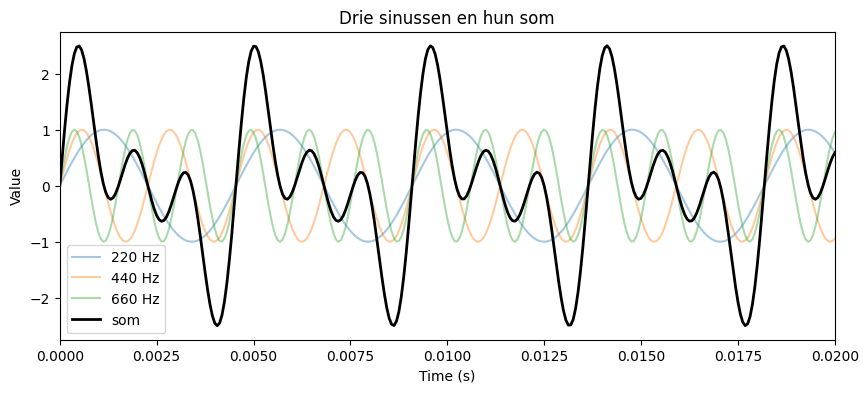

In [15]:
import matplotlib.pyplot as plt
import numpy as np


SAMPLERATE = 16000
duration = 1.0
samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)


def make_sine(frequency, amplitude=1.0, duration=1.0):
    samples = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
    wave = np.sin(2 * np.pi * frequency * samples) * amplitude
    return wave

f0 = 220
w1 = make_sine(f0)
w2 = make_sine(2 * f0)
w3 = make_sine(3 * f0)
total = w1 + w2 + w3

plt.figure(figsize=(10, 4))
plt.plot(samples, w1, label="220 Hz", alpha=0.4)
plt.plot(samples, w2, label="440 Hz", alpha=0.4)
plt.plot(samples, w3, label="660 Hz", alpha=0.4)
plt.plot(samples, total, label="som", linewidth=2, color="black")
plt.xlim(0, 0.02)
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.legend()
plt.title("Drie sinussen en hun som")
plt.show()

De zwarte lijn is de som. Geen sinus meer, maar een herhalend, ingewikkelder patroon. En toch herhaalt het zich nog steeds met dezelfde periode als de grondtoon — dat is precies waarom je nog 220 Hz hoort als toonhoogte.

### Wiskundige notatie

Wat we doen is kort op te schrijven als:

$$y(t) = \sum_{n=1}^{N} A_n \sin(2\pi \cdot n \cdot f_0 \cdot t)$$

Geen paniek bij dat $\sum$-teken: dat betekent gewoon "tel een aantal termen op". Voor $n = 1, 2, 3, \ldots, N$ neem je telkens een sinus met frequentie $n \cdot f_0$ en amplitude $A_n$, en je telt alles op.

In ons voorbeeld hierboven was $N = 3$ en alle $A_n = 1$.

### Oefening 3.1

Schrijf een functie `make_harmonic(fundamental, n)` die de $n$-de boventoon van een grondtoon teruggeeft. Dus `make_harmonic(220, 3)` moet hetzelfde geven als `make_sine(660)`.

### Oefening 3.2

Tel met behulp van `make_harmonic` de eerste vijf boventonen van 220 Hz op. Plot het resultaat (eerste 0.02 seconden) en speel het af.

## 4. Klankkleur: niet alle boventonen even hard

Tot nu toe gaven we elke boventoon dezelfde amplitude. Maar echte instrumenten doen dat niet. Een gitaar, een fluit, een klarinet: elk heeft een eigen "vingerafdruk" in welke boventonen sterk klinken en welke zwak.

Het verbluffende inzicht is dit: door alleen de **verhouding van de amplitudes** te variëren, kan je heel verschillende klanken maken — terwijl de toonhoogte gelijk blijft.

We gaan drie klassieke recepten bekijken.

### Recept 1: de zaagtand

Neem alle boventonen, maar geef de $n$-de boventoon amplitude $\frac{1}{n}$:

$$y(t) = \sum_{n=1}^{N} \frac{1}{n}\sin(2\pi \cdot n \cdot f_0 \cdot t)$$

Dus de eerste hard, de tweede half zo hard, de derde een derde, en zo verder.

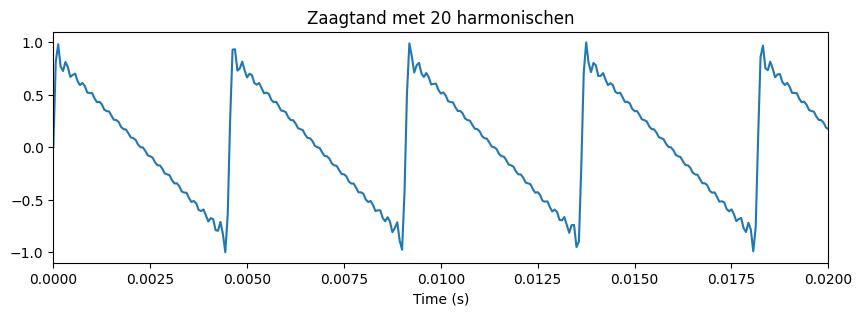

In [32]:
f0 = 220
N = 20

wave = np.zeros_like(samples)
for n in range(1, N + 1):
    wave = wave + make_sine(n * f0, amplitude=1/n)

wave = wave / np.max(np.abs(wave))

plt.figure(figsize=(10, 3))
plt.plot(samples, wave)
plt.xlim(0, 0.02)
plt.xlabel("Time (s)")
plt.title("Zaagtand met 20 harmonischen")
plt.show()

sd.play(wave, SAMPLERATE)
sd.wait()

Kijk eens naar de vorm: het lijkt op de tanden van een zaag. Vandaar de naam. En klanklijk: scherp, "buzzig", lijkt op een synthesizer of een ruwe strijkklank.

### Recept 2: de blokgolf

Neem **alleen de oneven** boventonen, met amplitude $\frac{1}{n}$:

$$y(t) = \sum_{n \text{ oneven}} \frac{1}{n}\sin(2\pi \cdot n \cdot f_0 \cdot t)$$

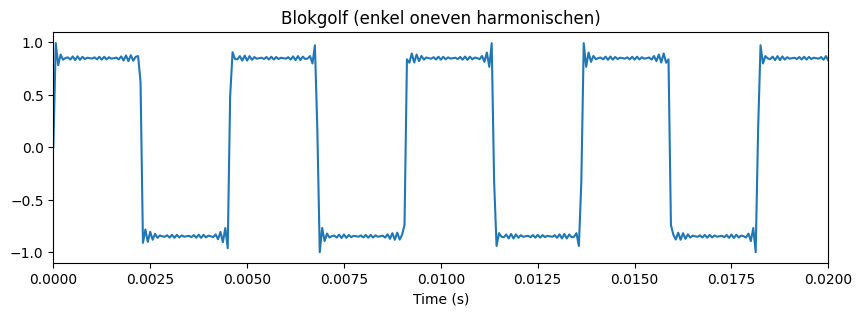

In [19]:
wave = np.zeros_like(samples)
for n in range(1, 40, 2):   # 1, 3, 5, 7, ...
    wave = wave + (1/n) * make_sine(n * f0)

wave = wave / np.max(np.abs(wave))

plt.figure(figsize=(10, 3))
plt.plot(samples, wave)
plt.xlim(0, 0.02)
plt.xlabel("Time (s)")
plt.title("Blokgolf (enkel oneven harmonischen)")
plt.show()

sd.play(wave, SAMPLERATE)
sd.wait()

Een vlakke top en een vlakke bodem — een *blokgolf*. Klinkt hol, doet aan een klarinet of een oude videogame denken.

### Recept 3: de driehoeksgolf

Neem opnieuw alleen de oneven boventonen, maar nu met amplitude $\frac{1}{n^2}$:

$$y(t) = \sum_{n \text{ oneven}} \frac{1}{n^2}\sin(2\pi \cdot n \cdot f_0 \cdot t)$$

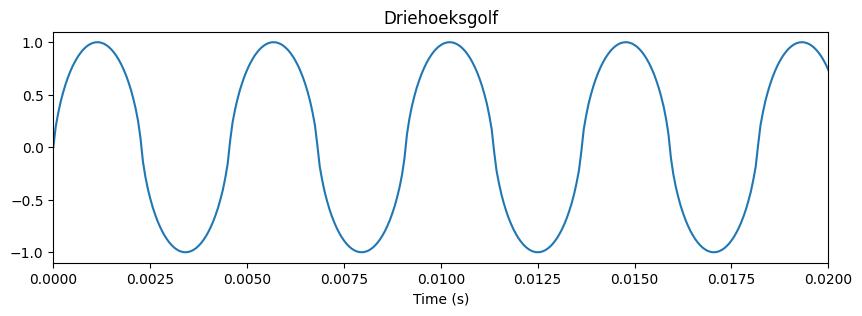

In [21]:
wave = np.zeros_like(samples)
for n in range(1, 40, 2):
    wave = wave + (1/(n*n)) * make_sine(n * f0)

wave = wave / np.max(np.abs(wave))

plt.figure(figsize=(10, 3))
plt.plot(samples, wave)
plt.xlim(0, 0.02)
plt.xlabel("Time (s)")
plt.title("Driehoeksgolf")
plt.show()

sd.play(wave, SAMPLERATE)
sd.wait()

Driehoekig van vorm, en vrij zacht van klank — dichter bij een fluit.

### Wat valt op?

Drie verschillende geluiden, alle drie opgebouwd uit dezelfde grondtoon en boventonen. Het verschil zit puur in de *amplitudeverhouding* tussen de boventonen.

Dit is geen toeval: een resultaat uit de wiskunde — de **Fourier-reeks** — zegt dat élke periodieke functie zo geschreven kan worden als een som van sinussen. Hoe complex je golf ook is, met genoeg sinussen kan je ze nabouwen.

We gaan hier later in de cursus zeker nog op terugkomen.

### Het effect van $N$

We hebben hierboven $N = 20$ of 40 termen genomen. Wat als we dat veranderen?

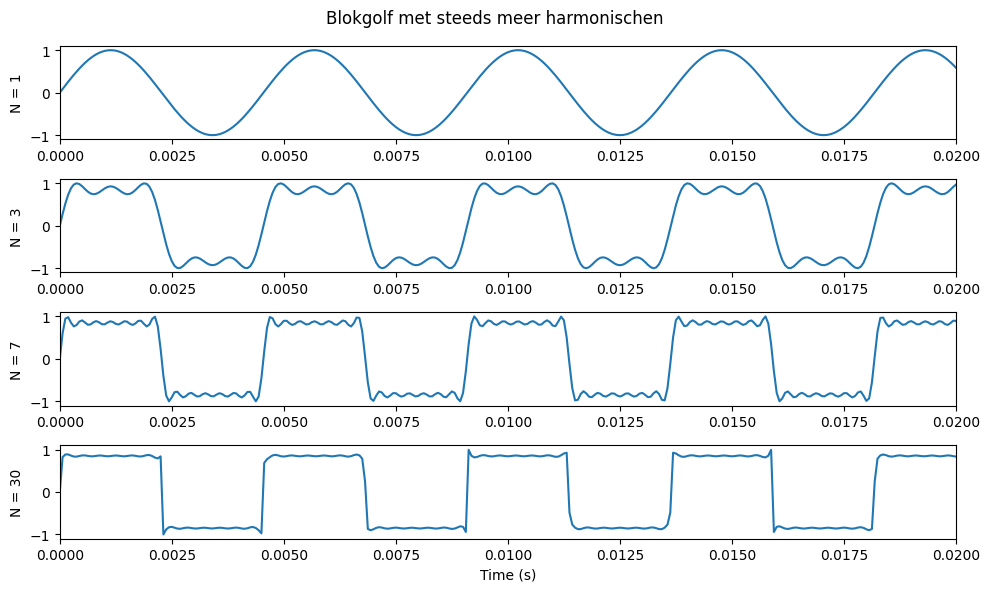

In [34]:
def square_wave(fundamental, n_harmonics):
    wave = np.zeros_like(samples)
    for n in range(1, 2 * n_harmonics, 2):
        wave = wave + make_sine(n * fundamental, amplitude=1/n)
    return wave / np.max(np.abs(wave))

plt.figure(figsize=(10, 6))
for i, N in enumerate([1, 3, 7, 30]):
    plt.subplot(4, 1, i + 1)
    plt.plot(samples, square_wave(220, N))
    plt.xlim(0, 0.02)
    plt.ylabel(f"N = {N}")
plt.xlabel("Time (s)")
plt.suptitle("Blokgolf met steeds meer harmonischen")
plt.tight_layout()
plt.show()

Met één harmonische is het gewoon een sinus. Met drie zie je al iets dat op een blok lijkt. Met dertig is het bijna echt vierkant — de "kartels" rond de overgangen blijven echter zichtbaar. Hoe meer termen, hoe scherper de blok.

Beluister ook hoe het klinkt:

In [36]:
for N in [1, 3, 7, 30]:
    print(f"N = {N}")
    sd.play(square_wave(220, N), SAMPLERATE)
    sd.wait()

N = 1
N = 3
N = 7
N = 30


## 5. Je eigen "instrument" bouwen

Tijd om alles bij elkaar te leggen. We schrijven een functie die als parameter een frequentie krijgt, en intern jouw eigen mix van harmonischen produceert. Dat is jouw "instrument".

Een voorbeeld om mee te starten:

In [37]:
def my_instrument(frequency, duration=1.0):
    t = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
    # mijn eigen amplitudemix per harmonische:
    amplitudes = [1.0, 0.6, 0.4, 0.2, 0.15, 0.1]
    
    wave = np.zeros_like(t)
    for n, amp in enumerate(amplitudes, start=1):
        wave = wave + amp * np.sin(2 * np.pi * n * frequency * t)
    
    return wave / np.max(np.abs(wave))

note = my_instrument(220)
sd.play(note, SAMPLERATE)
sd.wait()

Merk op dat we hier `t` *binnen* de functie maken. Daardoor werkt de functie ook met andere durations zonder van een globale variabele af te hangen. Dat is netter.

### Een melodie spelen

Met `np.concatenate` kan je verschillende arrays achter elkaar plakken. Zo speel je een eenvoudige melodie:

In [38]:
# eerste 4 noten van Frère Jacques: do - re - mi - do
do = my_instrument(261.63, 0.5)
re = my_instrument(293.66, 0.5)
mi = my_instrument(329.63, 0.5)

melody = np.concatenate([do, re, mi, do])
sd.play(melody, SAMPLERATE)
sd.wait()

Saai? Voeg een korte exponentiële demping toe (zoals in vorige les), dan klinkt het meer "aangeslagen" in plaats van als een orgel:

In [39]:
def my_instrument_plucked(frequency, duration=1.0, decay=5.0):
    t = np.linspace(0, duration, int(SAMPLERATE * duration), endpoint=False)
    amplitudes = [1.0, 0.6, 0.4, 0.2, 0.15, 0.1]
    
    wave = np.zeros_like(t)
    for n, amp in enumerate(amplitudes, start=1):
        wave = wave + amp * np.sin(2 * np.pi * n * frequency * t)
    
    envelope = np.exp(-decay * t)
    wave = wave * envelope
    return wave / np.max(np.abs(wave))

melody = np.concatenate([
    my_instrument_plucked(261.63, 0.5),
    my_instrument_plucked(293.66, 0.5),
    my_instrument_plucked(329.63, 0.5),
    my_instrument_plucked(261.63, 0.5),
])
sd.play(melody, SAMPLERATE)
sd.wait()

Voilà — geen orgel meer maar iets dat al meer als een "tokkel"-instrument klinkt.

## 6. Oefeningen

### Oefening 6.1 — Twee karakters

Ontwerp twee verschillende `my_instrument`-functies:

* één die volgens jou **warm** klinkt (denk: weinig hoge boventonen)
* één die **scherp** klinkt (denk: veel hoge boventonen)

Test ze allebei op dezelfde frequentie.

### Oefening 6.2 - Een melodie

Kies een eenvoudige melodie en speel ze af met jouw eigen instrument.

Frequenties van de noten kan je opzoeken, of je berekent ze zelf vanuit een referentie. Een handige tabel:

| Noot | Frequentie (Hz) |
|------|-----------------|
| C4 (centrale do) | 261.63 |
| D4 | 293.66 |
| E4 | 329.63 |
| F4 | 349.23 |
| G4 | 392.00 |
| A4 | 440.00 |
| B4 | 493.88 |
| C5 | 523.25 |

### Oefening 6.3 — Een toonladder

Op een piano of gitaar zijn opeenvolgende halve tonen verbonden door:

$$f_{n+1} = f_n \cdot \sqrt[12]{2}$$

Een octaaf (12 halve tonen omhoog) is dus een verdubbeling van de frequentie.

Schrijf een lus die, beginnend bij 220 Hz, een chromatische toonladder van 13 noten speelt (12 halve tonen omhoog, eindigend op 440 Hz). Gebruik jouw `my_instrument_plucked`.

*Hint:* `2 ** (1/12)` geeft de factor.

### Oefening 6.4 — Vergelijking met een echte blokgolf

Numpy heeft een `np.sign`-functie die positieve getallen op 1 zet en negatieve op -1. Daarmee kan je een "perfecte" blokgolf maken: `np.sign(np.sin(2 * np.pi * f0 * samples))`.

Plot in één figuur de echte blokgolf én jouw `square_wave(220, 30)`. Wat valt je op rond de overgangen tussen +1 en −1?

---

## Wat heb je geleerd?

* Functies zijn herbruikbare recepten met parameters en een `return`-waarde. Default-waarden geven je flexibiliteit zonder elke keer alles in te stellen.
* Een **boventoon** is een sinus waarvan de frequentie een geheel veelvoud is van de grondtoon.
* **Klankkleur** ontstaat door de amplitudeverhouding van de boventonen. Dezelfde grondtoon kan op heel verschillende manieren klinken.
* Drie standaardgolven — zaagtand, blokgolf, driehoeksgolf — zijn elk een specifieke optelsom van sinussen.
* Dit is een glimp van de **Fourier-reeks**: élke periodieke golf is een som van sinussen. Daar komen we later op terug.